# Notebook 10.2: Overfitting Forensics: The Parameter Sensitivity Test

## Financial Trading with Python, 2nd Edition

---

A strategy that only works at one precise parameter setting is not a strategy. It is a coincidence.

This notebook demonstrates how to detect overfitting after the fact using a parameter sensitivity test. We take a simple two-parameter SMA crossover strategy on SPY, find the optimal parameter set in-sample, and then ask two questions:

- Does that parameter set hold up out of sample?
- Does performance degrade gracefully as we move away from the optimal parameters, or does it collapse immediately?

The answers tell us whether we found a real edge or just fit noise.

This notebook covers:

- Setting up an explicit in-sample and out-of-sample split
- Running an in-sample grid search over SMA window pairs
- Testing the optimal parameters on the holdout period
- Visualizing the full parameter sensitivity surface in-sample vs. out-of-sample
- The neighbor test: what happens when we move one step away from the optimal parameters

## Section 1: Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings

warnings.filterwarnings('ignore')
sns.set_theme()

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Parameters ────────────────────────────────────────────────────────────────
TICKER     = 'SPY'
START_DATE = '2005-01-01'
END_DATE   = '2025-12-31'

# Train/test split date defined up front before any optimization.
# Defining this before touching the data is non-negotiable: choosing
# the split after seeing results is a form of data snooping.
SPLIT_DATE = '2019-01-01'

# SMA grid search parameters
FAST_WINDOWS = [5, 10, 15, 20, 30]
SLOW_WINDOWS = [30, 50, 75, 100, 150, 200]

# ── Data loading ──────────────────────────────────────────────────────────────
spy = yf.download(TICKER, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)
prices = spy['Close'].squeeze()

# Split into in-sample and out-of-sample periods
prices_is  = prices[prices.index <  SPLIT_DATE]   # in-sample: 2005-2018
prices_oos = prices[prices.index >= SPLIT_DATE]   # out-of-sample: 2019-2025

print(f"Total data:       {len(prices)} trading days")
print(f"In-sample:        {len(prices_is)} days "
      f"({prices_is.index[0].date()} to {prices_is.index[-1].date()})")
print(f"Out-of-sample:    {len(prices_oos)} days "
      f"({prices_oos.index[0].date()} to {prices_oos.index[-1].date()})")

Total data:       5282 trading days
In-sample:        3523 days (2005-01-03 to 2018-12-31)
Out-of-sample:    1759 days (2019-01-02 to 2025-12-30)


We have a clean split:

- 3,523 in-sample days covering 2005-2018, including the 2008 financial crisis and the post-crisis recovery
- 1,759 out-of-sample days covering 2019-2025, including the 2020 COVID crash and the 2022 rate cycle

The split date is defined before any optimization. This is the most important discipline in walk-forward testing: the holdout period must be invisible during parameter selection. If you choose the split after seeing how different periods perform, the "out-of-sample" test is no longer out of sample.

## Section 2: The SMA Crossover Strategy

The strategy is a simple two-parameter SMA crossover:

- Go long SPY when the fast SMA crosses above the slow SMA
- Go flat when the fast SMA crosses below the slow SMA

We need two functions: one to compute the strategy returns for a given parameter pair, and one to compute headline metrics. We will call these repeatedly across the full parameter grid.

*Note: we are assuming a 0% return for the risk-free rate*

In [4]:
def compute_sma_returns(prices: pd.Series, fast: int, slow: int) -> pd.Series:
    """
    Compute daily log returns for a simple SMA crossover strategy.

    Parameters:
    -----------
    prices : daily close price series
    fast   : fast SMA window in trading days
    slow   : slow SMA window in trading days

    Returns:
    --------
    Series of daily log returns for the strategy.
    """
    # Compute both moving averages
    sma_fast = prices.rolling(window=fast).mean()
    sma_slow = prices.rolling(window=slow).mean()

    # Signal: 1 when fast > slow (uptrend), 0 otherwise
    signal = (sma_fast > sma_slow).astype(float)

    # Shift by 1 day to avoid lookahead: signal on day t trades on day t+1
    signal = signal.shift(1)

    # Log returns of the underlying
    log_returns = np.log(prices / prices.shift(1))

    # Strategy returns: long when signal=1, flat when signal=0
    strat_returns = signal * log_returns

    return strat_returns.dropna()


def compute_sharpe(returns: pd.Series, trading_days: int = 252) -> float:
    """
    Compute annualized Sharpe ratio from daily log returns.
    Returns NaN if standard deviation is zero (flat strategy).
    """
    if returns.std() == 0:
        return np.nan
    return (returns.mean() / returns.std()) * np.sqrt(trading_days)


# ── Quick sanity check on a single parameter pair ─────────────────────────────
test_returns = compute_sma_returns(prices_is, fast=20, slow=100)
test_sharpe  = compute_sharpe(test_returns)

print(f"Test pair (fast=20, slow=100):")
print(f"  In-sample Sharpe: {test_sharpe:.4f}")
print(f"  Return observations: {len(test_returns)}")

Test pair (fast=20, slow=100):
  In-sample Sharpe: 0.4916
  Return observations: 3522


## Section 3: In-Sample Grid Search

We loop over all valid fast/slow pairs (where fast < slow) and compute the in-sample Sharpe for each. The result is a matrix of Sharpe ratios indexed by parameter pair, which we will visualize as a heatmap.

In [5]:
# ── In-sample grid search ─────────────────────────────────────────────────────
# Loop over all valid parameter pairs and store the in-sample Sharpe.
# Only test pairs where fast < slow: a crossover with fast >= slow is meaningless.

results_is = {}

for fast in FAST_WINDOWS:
    for slow in SLOW_WINDOWS:
        if fast >= slow:
            continue   # skip invalid pairs
        returns = compute_sma_returns(prices_is, fast, slow)
        results_is[(fast, slow)] = compute_sharpe(returns)

# Convert to DataFrame for easy plotting and inspection
df_is = pd.Series(results_is, name='Sharpe').unstack()
df_is.index.name   = 'Fast Window'
df_is.columns.name = 'Slow Window'

print("In-sample Sharpe ratios by parameter pair:\n")
print(df_is.round(3).to_string())

# ── Identify the optimal pair ──────────────────────────────────────────────────
best_pair   = max(results_is, key=results_is.get)
best_sharpe = results_is[best_pair]
print(f"\nOptimal in-sample pair: fast={best_pair[0]}, slow={best_pair[1]}")
print(f"In-sample Sharpe:       {best_sharpe:.4f}")

In-sample Sharpe ratios by parameter pair:

Slow Window    30     50     75     100    150    200
Fast Window                                          
5           0.3830 0.3840 0.6040 0.6350 0.4840 0.5940
10          0.3780 0.3640 0.7870 0.5850 0.5490 0.6660
15          0.4080 0.4650 0.5650 0.5340 0.5700 0.6350
20          0.5590 0.3800 0.4930 0.4920 0.5630 0.6680
30             NaN 0.3320 0.5350 0.4510 0.5480 0.7310

Optimal in-sample pair: fast=10, slow=75
In-sample Sharpe:       0.7867


The in-sample grid produces Sharpe ratios ranging from 0.33 to 0.79 across the parameter space. The optimal pair is fast=10, slow=75 with a Sharpe of 0.787.

A few things to note before we get excited about that number:

- The surface is not smooth: nearby pairs produce very different Sharpes (fast=10, slow=50 gives 0.364 while fast=10, slow=75 gives 0.787)
- That jaggedness is a warning sign. A real edge tends to produce a smooth, gradually sloping surface. Sharp peaks suggest the optimizer found a quirk in the data rather than a systematic pattern.
- We have not looked at the out-of-sample period yet. The split date was defined before this search and has not been touched.

Next we visualize the full surface as a heatmap.

## Section 4: Visualizing the In-Sample Parameter Surface

A heatmap of the full parameter grid makes the shape of the surface immediately visible. We are looking for one of two patterns:

- A plateau: performance is strong across a wide region of the parameter space. This suggests a real edge that is not sensitive to the exact parameter choice.
- A spike: one or two cells are dramatically better than their neighbors. This suggests the optimizer found noise.

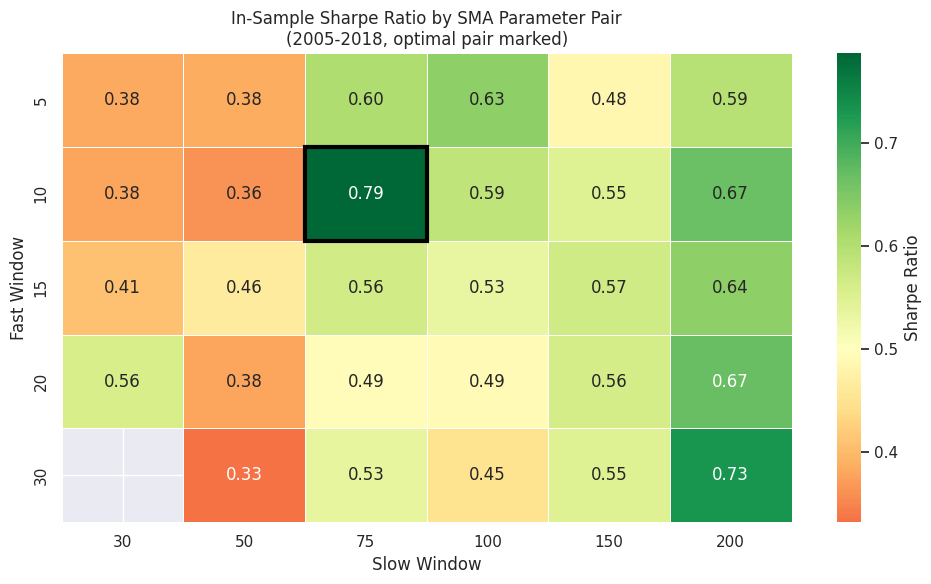

In [6]:
# ── In-sample Sharpe heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(df_is,
            annot=True, fmt='.2f',
            cmap='RdYlGn',           # red = low, green = high
            center=0.5,              # center the colormap at a moderate Sharpe
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Sharpe Ratio'})

# Mark the optimal cell
opt_fast_idx = list(df_is.index).index(best_pair[0])
opt_slow_idx = list(df_is.columns).index(best_pair[1])
ax.add_patch(plt.Rectangle((opt_slow_idx, opt_fast_idx), 1, 1,
                            fill=False, edgecolor='black', lw=3,
                            label=f'Optimal: ({best_pair[0]}, {best_pair[1]})'))

ax.set_title(f'In-Sample Sharpe Ratio by SMA Parameter Pair\n'
             f'(2005-2018, optimal pair marked)')
ax.set_xlabel('Slow Window')
ax.set_ylabel('Fast Window')

plt.tight_layout()
plt.savefig('fig_10_3_is_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

The heatmap shows a clear spike pattern rather than a plateau:

- The optimal cell (fast=10, slow=75) at 0.79 stands out sharply from its neighbors
- fast=10, slow=50 produces a Sharpe of only 0.36, less than half the optimal value
- fast=10, slow=100 drops to 0.59
- Moving one step in either direction from the optimal cell produces a significant drop

Compare this to the bottom-right region of the heatmap (fast=30, slow=200 at 0.73): that cell sits within a broader green region where nearby parameters also perform reasonably well. That is closer to what a robust edge looks like.

The optimal pair at (10, 75) does not have that property. Its performance is isolated. Before we draw any conclusions, we need to see what happens when we apply it to the out-of-sample period.

## Section 5: Out-of-Sample Test

We now open the holdout period for the first time. The optimal parameter pair from the in-sample grid search (fast=10, slow=75) is applied to the 2019-2025 data without any modification.

In [7]:
# ── Run full OOS grid search ───────────────────────────────────────────────────
# We run the full grid on the OOS period as well, not just the optimal pair.
# This lets us compare the full surface in-sample vs. out-of-sample,
# which is more informative than a single point comparison.

results_oos = {}

for fast in FAST_WINDOWS:
    for slow in SLOW_WINDOWS:
        if fast >= slow:
            continue
        returns = compute_sma_returns(prices_oos, fast, slow)
        results_oos[(fast, slow)] = compute_sharpe(returns)

df_oos = pd.Series(results_oos, name='Sharpe').unstack()
df_oos.index.name   = 'Fast Window'
df_oos.columns.name = 'Slow Window'

# ── Optimal pair performance in both periods ───────────────────────────────────
oos_sharpe_optimal = results_oos[best_pair]
spy_is_returns  = np.log(prices_is  / prices_is.shift(1)).dropna()
spy_oos_returns = np.log(prices_oos / prices_oos.shift(1)).dropna()

print(f"Optimal pair (fast={best_pair[0]}, slow={best_pair[1]}):")
print(f"  In-sample Sharpe (2005-2018):     {best_sharpe:.4f}")
print(f"  Out-of-sample Sharpe (2019-2025): {oos_sharpe_optimal:.4f}")
print(f"\nSPY buy-and-hold Sharpe:")
print(f"  In-sample:     {compute_sharpe(spy_is_returns):.4f}")
print(f"  Out-of-sample: {compute_sharpe(spy_oos_returns):.4f}")
print(f"\nOut-of-sample Sharpe ratios by parameter pair:\n")
print(df_oos.round(3).to_string())

Optimal pair (fast=10, slow=75):
  In-sample Sharpe (2005-2018):     0.7867
  Out-of-sample Sharpe (2019-2025): 0.7546

SPY buy-and-hold Sharpe:
  In-sample:     0.3881
  Out-of-sample: 0.8069

Out-of-sample Sharpe ratios by parameter pair:

Slow Window    30     50     75     100    150    200
Fast Window                                          
5           0.8480 0.7780 0.5880 0.8110 1.0540 0.7980
10          0.7780 0.7930 0.7550 0.9810 0.8120 0.8380
15          0.7280 0.6180 0.6830 0.6600 0.7210 0.7100
20          0.6820 0.5810 0.5730 0.7360 0.6720 0.6070
30             NaN 0.6200 0.6090 0.6870 0.6190 0.5380


The results are more nuanced than a simple "optimal in-sample, terrible out-of-sample" story, and that makes them more realistic:

- The optimal in-sample pair (fast=10, slow=75) held up reasonably well OOS with a Sharpe of 0.755
- However SPY buy-and-hold delivered a Sharpe of 0.807 OOS, outperforming the optimized strategy without any parameter selection
- The OOS surface looks nothing like the in-sample surface: the top OOS performers are (5, 150) at 1.054 and (10, 100) at 0.981, neither of which ranked highly in-sample
- The in-sample optimization did not find the worst OOS parameters, but it did not find the best ones either

This is the typical pattern in practice:

- Optimization rarely produces a catastrophic OOS failure
- It more commonly produces a result that looks reasonable but could have been beaten by simpler choices
- The surface reshuffles: what was optimal in one period has no special claim on the next
- Paying the cost of optimization (complexity, overfitting risk) without capturing its benefit is the real danger

Next we visualize both surfaces side by side to make this reshuffling visible.

## Section 6: Comparing the In-Sample and Out-of-Sample Surfaces

Plotting both heatmaps side by side makes the surface reshuffling immediately visible. A robust strategy would show a similar pattern in both panels. An overfit strategy shows a peak in one place in-sample and a completely different pattern out-of-sample.

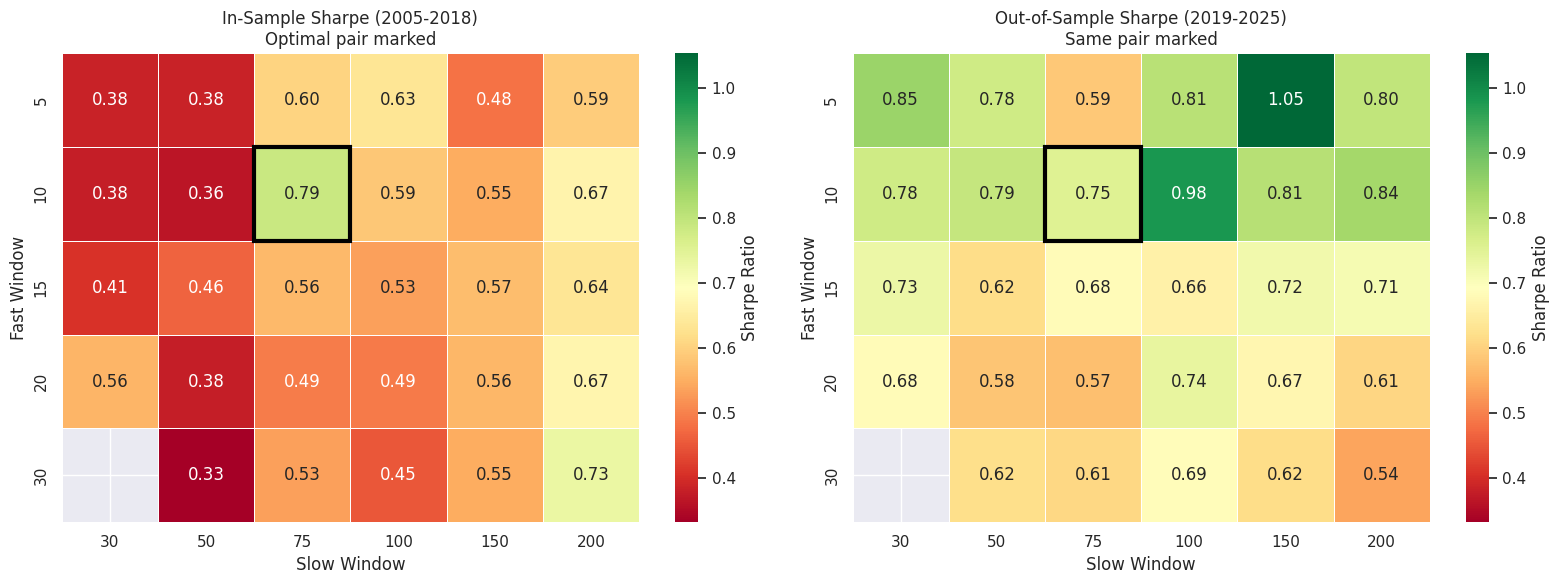

In [8]:
# ── Side-by-side heatmaps ──────────────────────────────────────────────────────
# Using the same color scale for both panels so the comparison is fair.
# vmin and vmax are set to the global min and max across both surfaces.

vmin = min(df_is.min().min(), df_oos.min().min())
vmax = max(df_is.max().max(), df_oos.max().max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# In-sample heatmap
sns.heatmap(df_is,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            vmin=vmin, vmax=vmax,
            linewidths=0.5,
            ax=axes[0],
            cbar_kws={'label': 'Sharpe Ratio'})

# Mark the optimal in-sample cell
axes[0].add_patch(plt.Rectangle((opt_slow_idx, opt_fast_idx), 1, 1,
                                 fill=False, edgecolor='black', lw=3))
axes[0].set_title('In-Sample Sharpe (2005-2018)\nOptimal pair marked')
axes[0].set_xlabel('Slow Window')
axes[0].set_ylabel('Fast Window')

# Out-of-sample heatmap
sns.heatmap(df_oos,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            vmin=vmin, vmax=vmax,
            linewidths=0.5,
            ax=axes[1],
            cbar_kws={'label': 'Sharpe Ratio'})

# Mark the same optimal cell on the OOS heatmap to show where it lands
axes[1].add_patch(plt.Rectangle((opt_slow_idx, opt_fast_idx), 1, 1,
                                 fill=False, edgecolor='black', lw=3))
axes[1].set_title('Out-of-Sample Sharpe (2019-2025)\nSame pair marked')
axes[1].set_xlabel('Slow Window')
axes[1].set_ylabel('Fast Window')

plt.tight_layout()
plt.savefig('fig_10_4_is_vs_oos_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

The two surfaces tell completely different stories:

- In-sample (left): the optimal cell (10, 75) stands out as a dark green spike surrounded by lighter cells. The bottom-left region (short fast windows, short slow windows) is dominated by red and orange.
- Out-of-sample (right): the entire surface shifts upward and the pattern inverts. The top-left region that was red in-sample is now green. The optimal in-sample cell (marked) is now a mid-range performer surrounded by better options.

Three observations worth noting:

- The OOS surface is more uniform than the in-sample surface. Most parameter pairs produce Sharpe ratios between 0.55 and 1.05. The in-sample optimization had a much wider range to exploit (0.33 to 0.79).
- The best OOS pair (5, 150) at 1.054 was not even close to optimal in-sample at 0.484. Selecting parameters in-sample actively excluded the best OOS option.
- The worst in-sample region (short slow windows) became the best OOS region. This kind of inversion is a strong sign that the in-sample optimization was fitting the specific price path of 2005-2018, not a persistent structural pattern.

Next we run the neighbor test on the optimal pair to show how sensitive it is to small parameter changes.

## Section 7: The Neighbor Test

The neighbor test asks a simple question: if we move one step away from the optimal parameter in either direction, how much does performance change?

A robust strategy degrades gracefully. An overfit strategy collapses. We extract the row and column centered on the optimal pair and plot in-sample vs. out-of-sample Sharpe for each.

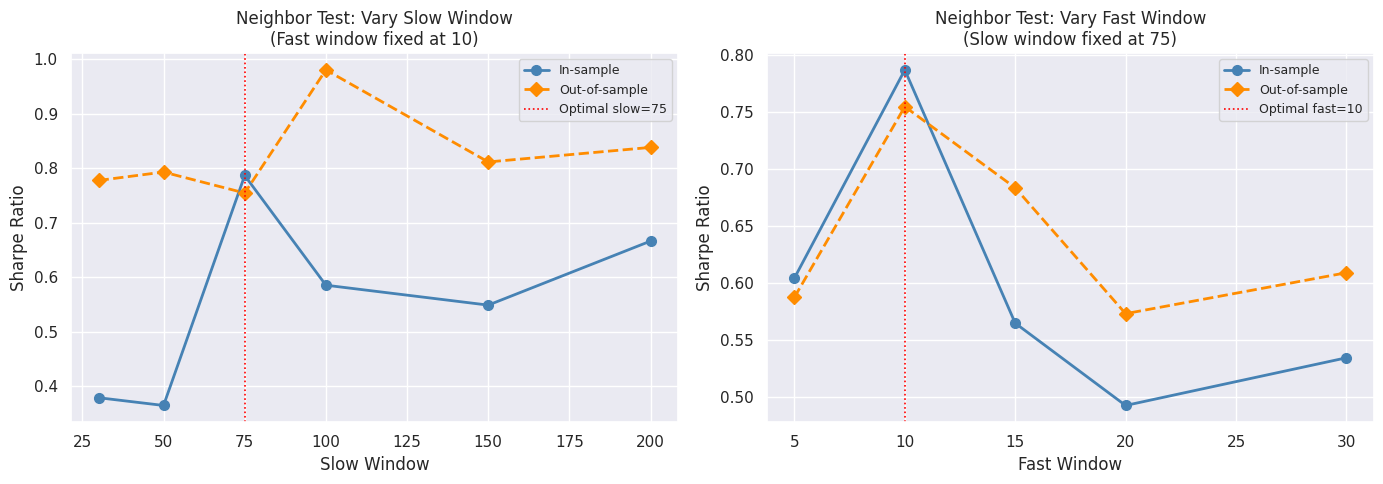

Optimal pair (fast=10, slow=75): IS=0.787, OOS=0.755

Neighbors varying slow window (fast fixed at 10):
  slow= 30: IS=0.378, OOS=0.778
  slow= 50: IS=0.364, OOS=0.793
  slow=100: IS=0.585, OOS=0.981
  slow=150: IS=0.549, OOS=0.812
  slow=200: IS=0.666, OOS=0.838


In [9]:
# ── Neighbor test ─────────────────────────────────────────────────────────────
# Extract the row (varying slow window, fixed fast=10) and
# column (varying fast window, fixed slow=75) through the optimal pair.

opt_fast, opt_slow = best_pair   # (10, 75)

# Row: fix fast window at optimal, vary slow window
row_is  = df_is.loc[opt_fast]
row_oos = df_oos.loc[opt_fast]

# Column: fix slow window at optimal, vary fast window
col_is  = df_is[opt_slow].dropna()
col_oos = df_oos[opt_slow].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left panel: vary slow window (fast fixed at 10) ───────────────────────────
axes[0].plot(row_is.index,  row_is.values,
             color='steelblue', linewidth=2, linestyle='solid',
             marker='o', markersize=7, label='In-sample')
axes[0].plot(row_oos.index, row_oos.values,
             color='darkorange', linewidth=2, linestyle='dashed',
             marker='D', markersize=7, label='Out-of-sample')

# Mark the optimal slow window
axes[0].axvline(opt_slow, color='red', linewidth=1.2,
                linestyle='dotted', label=f'Optimal slow={opt_slow}')

axes[0].set_title(f'Neighbor Test: Vary Slow Window\n(Fast window fixed at {opt_fast})')
axes[0].set_xlabel('Slow Window')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].legend(fontsize=9)

# ── Right panel: vary fast window (slow fixed at 75) ──────────────────────────
axes[1].plot(col_is.index,  col_is.values,
             color='steelblue', linewidth=2, linestyle='solid',
             marker='o', markersize=7, label='In-sample')
axes[1].plot(col_oos.index, col_oos.values,
             color='darkorange', linewidth=2, linestyle='dashed',
             marker='D', markersize=7, label='Out-of-sample')

axes[1].axvline(opt_fast, color='red', linewidth=1.2,
                linestyle='dotted', label=f'Optimal fast={opt_fast}')

axes[1].set_title(f'Neighbor Test: Vary Fast Window\n(Slow window fixed at {opt_slow})')
axes[1].set_xlabel('Fast Window')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_10_5_neighbor_test.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Quantify the drop to nearest neighbors ────────────────────────────────────
# Find the neighbors immediately adjacent to the optimal pair
slow_neighbors = [s for s in SLOW_WINDOWS if s != opt_slow]
fast_neighbors = [f for f in FAST_WINDOWS if f != opt_fast and f < opt_slow]

print(f"Optimal pair (fast={opt_fast}, slow={opt_slow}): IS={best_sharpe:.3f}, OOS={results_oos[best_pair]:.3f}")
print(f"\nNeighbors varying slow window (fast fixed at {opt_fast}):")
for s in SLOW_WINDOWS:
    if s == opt_slow:
        continue
    is_val  = results_is.get((opt_fast, s), np.nan)
    oos_val = results_oos.get((opt_fast, s), np.nan)
    print(f"  slow={s:>3}: IS={is_val:.3f}, OOS={oos_val:.3f}")

The neighbor test reveals the full picture:

Left panel (vary slow window, fast fixed at 10):

- The in-sample blue line spikes sharply at slow=75 and drops immediately in both directions. Moving to slow=50 cuts the Sharpe from 0.787 to 0.364. Moving to slow=100 drops it to 0.585.
- The OOS orange line tells the opposite story: slow=75 sits at the bottom of the OOS curve. slow=100 produces a Sharpe of 0.981 OOS vs. 0.585 in-sample. The parameter the optimizer selected is the worst choice for the holdout period.

Right panel (vary fast window, slow fixed at 75):

- The in-sample line again spikes at fast=10 and falls off on both sides
- The OOS line is flatter but shows the same inversion: fast=10 is the best in-sample choice and a mid-range OOS choice

The pattern is consistent across both parameters:

- The optimal in-sample pair sits at a sharp local maximum in-sample
- That same point is unremarkable or below average out-of-sample
- The OOS surface does not have a peak near the in-sample optimum

This is the defining characteristic of an overfit parameter set. A real edge would show a plateau: nearby parameters would perform similarly, and the in-sample and OOS lines would roughly track each other. Here they do the opposite.

## Section 8: Key Takeaways

This notebook demonstrated overfitting through a parameter sensitivity test on a simple SMA crossover strategy.

Key points:

- The optimal in-sample pair (fast=10, slow=75) held up reasonably well OOS with a Sharpe of 0.755, but SPY buy-and-hold delivered 0.807 OOS without any optimization
- The full parameter surface reshuffled completely between the in-sample and OOS periods: the best in-sample parameters were not the best OOS parameters
- The neighbor test showed a sharp spike in-sample that collapsed immediately in both directions, the defining signature of an overfit parameter set
- A robust edge shows a plateau: performance should degrade gradually as parameters move away from the optimal, not collapse immediately

The practical checklist when evaluating an optimized strategy:

- Run the neighbor test: move one step in each direction from the reported optimal and check whether performance degrades gracefully or collapses
- Compare the full in-sample and OOS surfaces: do they show similar patterns or do they invert?
- Ask whether the optimizer could have beaten a simple buy-and-hold without any parameter selection
- Be skeptical of any parameter that sits at a sharp local maximum with no nearby support

One more thing worth emphasizing. It is easy to underestimate how important these sensitivity tests are in practice. Deploying a strategy because you found the best parameter set in-sample will likely lose you money. This is not a lesson you want to learn the hard way.

Sadly, most strategies that depend on precise parameter settings will fail this test. This is one of the core reasons why strategies derived from technical analysis rules rarely hold up in live trading.